In [1]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, spearmanr, kendalltau
from sklearn import preprocessing
import scipy.stats as stats

## cox-violent-parsed

- jail in
- jail out
- charge degree
- charge desc

In [ ]:
data_violent = pd.read_csv('data/cox-violent-parsed.csv')
print(data_violent.columns)
data_violent

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_type_of_assessment,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event
0,1.0,miguel hernandez,miguel,hernandez,14/08/2013,Male,18/04/1947,69,Greater than 45,Other,...,Risk of Violence,1,Low,14/08/2013,07/07/2014,14/07/2014,0,0,327,0
1,2.0,miguel hernandez,miguel,hernandez,14/08/2013,Male,18/04/1947,69,Greater than 45,Other,...,Risk of Violence,1,Low,14/08/2013,07/07/2014,14/07/2014,0,334,961,0
2,3.0,michael ryan,michael,ryan,31/12/2014,Male,06/02/1985,31,25 - 45,Caucasian,...,Risk of Violence,2,Low,31/12/2014,30/12/2014,03/01/2015,0,3,457,0
3,4.0,kevon dixon,kevon,dixon,27/01/2013,Male,22/01/1982,34,25 - 45,African-American,...,Risk of Violence,1,Low,27/01/2013,26/01/2013,05/02/2013,0,9,159,1
4,5.0,ed philo,ed,philo,14/04/2013,Male,14/05/1991,24,Less than 25,African-American,...,Risk of Violence,3,Low,14/04/2013,16/06/2013,16/06/2013,4,0,63,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18311,NaN,alexsandra beauchamps,alexsandra,beauchamps,29/12/2014,Female,21/12/1984,31,25 - 45,African-American,...,Risk of Violence,4,Low,29/12/2014,28/12/2014,07/01/2015,5,9,459,0
18312,NaN,winston gregory,winston,gregory,14/01/2014,Male,01/10/1958,57,Greater than 45,Other,...,Risk of Violence,1,Low,14/01/2014,13/01/2014,14/01/2014,0,0,808,0
18313,NaN,farrah jean,farrah,jean,09/03/2014,Female,17/11/1982,33,25 - 45,African-American,...,Risk of Violence,2,Low,09/03/2014,08/03/2014,09/03/2014,3,0,754,0
18314,NaN,florencia sanmartin,florencia,sanmartin,30/06/2014,Female,18/12/1992,23,Less than 25,Hispanic,...,Risk of Violence,4,Low,30/06/2014,15/03/2015,15/03/2015,2,0,258,0


In [3]:
data_violent.describe()

,id,age,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,is_recid,r_days_from_arrest,violent_recid,is_violent_recid,decile_score.1,v_decile_score,priors_count.1,start,end,event
count,11001.00000,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000,17019.000000,17449.000000,18316.000000,6359.000000,0.0,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000
mean,5501.00000,34.019273,0.076873,4.997052,0.098439,0.124263,3.913191,4.302485,57.694596,0.414774,19.961629,NaN,0.073105,4.997052,4.022822,3.913191,186.394901,625.210636,0.044715
std,3175.85949,11.667811,0.464272,2.937569,0.517639,0.524537,5.299864,81.159881,317.994694,0.576449,74.139695,NaN,0.260317,2.937569,2.614189,5.299864,283.373004,335.881439,0.206683
min,1.00000,18.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,-597.000000,0.000000,-1.000000,-1.000000,NaN,0.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000
25%,2751.00000,25.000000,0.000000,2.000000,0.000000,0.000000,0.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,2.000000,2.000000,0.000000,0.000000,364.000000,0.000000
50%,5501.00000,31.000000,0.000000,5.000000,0.000000,0.000000,2.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,5.000000,4.000000,2.000000,7.000000,634.000000,0.000000
75%,8251.00000,41.000000,0.000000,8.000000,0.000000,0.000000,5.000000,0.000000,2.000000,1.000000,1.000000,NaN,0.000000,8.000000,6.000000,5.000000,309.000000,897.000000,0.000000
max,11001.00000,96.000000,20.000000,10.000000,13.000000,17.000000,43.000000,1057.000000,9485.000000,1.000000,993.000000,NaN,1.000000,10.000000,10.000000,43.000000,1197.000000,1187.000000,1.000000


## cox-violent-parsed_filt

- jail in
- jail out
- charge degree
- charge desc

In [38]:
data_violent_filt = pd.read_csv('data/cox-violent-parsed_filt.csv')
data_violent_filt

,id,name,first,last,sex,dob,age,age_cat,race,juv_fel_count,...,vr_charge_desc,type_of_assessment,decile_score.1,score_text,screening_date,v_type_of_assessment,v_decile_score,v_score_text,priors_count.1,event
0,1.0,miguel hernandez,miguel,hernandez,Male,18/04/1947,69,Greater than 45,Other,0,...,NaN,Risk of Recidivism,1,Low,14/08/2013,Risk of Violence,1,Low,0,0
1,2.0,miguel hernandez,miguel,hernandez,Male,18/04/1947,69,Greater than 45,Other,0,...,NaN,Risk of Recidivism,1,Low,14/08/2013,Risk of Violence,1,Low,0,0
2,3.0,michael ryan,michael,ryan,Male,06/02/1985,31,25 - 45,Caucasian,0,...,NaN,Risk of Recidivism,5,Medium,31/12/2014,Risk of Violence,2,Low,0,0
3,4.0,kevon dixon,kevon,dixon,Male,22/01/1982,34,25 - 45,African-American,0,...,Felony Battery (Dom Strang),Risk of Recidivism,3,Low,27/01/2013,Risk of Violence,1,Low,0,1
4,5.0,ed philo,ed,philo,Male,14/05/1991,24,Less than 25,African-American,0,...,NaN,Risk of Recidivism,4,Low,14/04/2013,Risk of Violence,3,Low,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18311,NaN,alexsandra beauchamps,alexsandra,beauchamps,Female,21/12/1984,31,25 - 45,African-American,0,...,NaN,Risk of Recidivism,6,Medium,29/12/2014,Risk of Violence,4,Low,5,0
18312,NaN,winston gregory,winston,gregory,Male,01/10/1958,57,Greater than 45,Other,0,...,NaN,Risk of Recidivism,1,Low,14/01/2014,Risk of Violence,1,Low,0,0
18313,NaN,farrah jean,farrah,jean,Female,17/11/1982,33,25 - 45,African-American,0,...,NaN,Risk of Recidivism,2,Low,09/03/2014,Risk of Violence,2,Low,3,0
18314,NaN,florencia sanmartin,florencia,sanmartin,Female,18/12/1992,23,Less than 25,Hispanic,0,...,NaN,Risk of Recidivism,4,Low,30/06/2014,Risk of Violence,4,Low,2,0


In [11]:
race_count_recid = {}
race_count = {}
for race in data_violent_filt['race'].unique():
    data_choose = data_violent_filt[data_violent_filt['race'] == race]
    race_count[race] = len(data_choose)
    race_count_recid[race] = len(data_choose[data_choose['is_recid'] == 1])

In [12]:
for key in race_count.keys():
    print(f"Race: {key}: {race_count_recid[key]/race_count[key]}")

Race: Other: 0.3755813953488372
Race: Caucasian: 0.4065067367729215
Race: African-American: 0.5189459707895006
Race: Hispanic: 0.34114403859407305
Race: Asian: 0.2676056338028169
Race: Native American: 0.43859649122807015


In [5]:
list(data_violent_filt.columns)

['id',
 'name',
 'first',
 'last',
 'sex',
 'dob',
 'age',
 'age_cat',
 'race',
 'juv_fel_count',
 'decile_score',
 'juv_misd_count',
 'juv_other_count',
 'priors_count',
 'days_b_screening_arrest',
 'c_jail_in',
 'c_jail_out',
 'c_days_from_compas',
 'c_charge_degree',
 'c_charge_desc',
 'is_recid',
 'r_charge_degree',
 'r_days_from_arrest',
 'r_offense_date',
 'r_charge_desc',
 'r_jail_in',
 'violent_recid',
 'is_violent_recid',
 'vr_charge_degree',
 'vr_offense_date',
 'vr_charge_desc',
 'type_of_assessment',
 'decile_score.1',
 'score_text',
 'screening_date',
 'v_type_of_assessment',
 'v_decile_score',
 'v_score_text',
 'priors_count.1',
 'event']

In [14]:
data_cleaned = data_violent_filt[['name', 'sex', 'dob', 'race', 'c_jail_in', 'c_jail_out', 'c_charge_degree', 'c_charge_desc']]
data_cleaned['dob'] = pd.to_datetime(data_cleaned['dob'], format="%d/%m/%Y")
data_cleaned['c_jail_in'] = pd.to_datetime(data_cleaned['c_jail_in'], format="%d/%m/%Y %H:%M")
data_cleaned['c_jail_out'] = pd.to_datetime(data_cleaned['c_jail_out'], format="%d/%m/%Y %H:%M")
data_cleaned['jail_time'] = (data_cleaned['c_jail_out'] - data_cleaned['c_jail_in']).dt.total_seconds() / (3600)

/tmp/ipykernel_3247/824939206.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['dob'] = pd.to_datetime(data_cleaned['dob'], format="%d/%m/%Y")
/tmp/ipykernel_3247/824939206.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data_cleaned['c_jail_in'] = pd.to_datetime(data_cleaned['c_jail_in'], format="%d/%m/%Y %H:%M")
/tmp/ipykernel_3247/824939206.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value 

In [7]:
data_cleaned

,name,sex,dob,race,c_jail_in,c_jail_out,c_charge_degree,c_charge_desc,jail_time
0,miguel hernandez,Male,1947-04-18,Other,2013-08-13 06:03:00,2013-08-14 05:41:00,(F3),Aggravated Assault w/Firearm,23.633333
1,miguel hernandez,Male,1947-04-18,Other,2013-08-13 06:03:00,2013-08-14 05:41:00,(F3),Aggravated Assault w/Firearm,23.633333
2,michael ryan,Male,1985-02-06,Caucasian,NaT,NaT,NaN,NaN,NaN
3,kevon dixon,Male,1982-01-22,African-American,2013-01-26 03:45:00,2013-02-05 05:36:00,(F3),Felony Battery w/Prior Convict,241.850000
4,ed philo,Male,1991-05-14,African-American,2013-04-13 04:58:00,2013-04-14 07:02:00,(F3),Possession of Cocaine,26.066667
...,...,...,...,...,...,...,...,...,...
18311,alexsandra beauchamps,Female,1984-12-21,African-American,2014-12-28 10:14:00,2015-01-07 11:42:00,(M1),Battery,241.466667
18312,winston gregory,Male,1958-10-01,Other,2014-01-13 05:48:00,2014-01-14 07:49:00,(F2),Aggravated Battery / Pregnant,26.016667
18313,farrah jean,Female,1982-11-17,African-American,2014-03-08 08:06:00,2014-03-09 12:18:00,(M1),Battery on Law Enforc Officer,28.200000
18314,florencia sanmartin,Female,1992-12-18,Hispanic,2014-06-28 12:16:00,2014-06-30 11:19:00,(F3),Possession of Ethylone,47.050000


In [22]:
data_dummies = data_cleaned[['sex', 'race', 'c_charge_degree', 'c_charge_desc']]

In [23]:
data_dummies = pd.get_dummies(data_dummies, columns=['sex', 'race', 'c_charge_degree'], drop_first=False)
data_dummies

,c_charge_desc,sex_Female,sex_Male,race_African-American,race_Asian,race_Caucasian,race_Hispanic,race_Native American,race_Other,c_charge_degree_(CO3),...,c_charge_degree_(F3),c_charge_degree_(F5),c_charge_degree_(F6),c_charge_degree_(F7),c_charge_degree_(M1),c_charge_degree_(M2),c_charge_degree_(MO3),c_charge_degree_(NI0),c_charge_degree_(TCX),c_charge_degree_(X)
0,Aggravated Assault w/Firearm,False,True,False,False,False,False,False,True,False,...,True,False,False,False,False,False,False,False,False,False
1,Aggravated Assault w/Firearm,False,True,False,False,False,False,False,True,False,...,True,False,False,False,False,False,False,False,False,False
2,NaN,False,True,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,Felony Battery w/Prior Convict,False,True,True,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,Possession of Cocaine,False,True,True,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18311,Battery,True,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
18312,Aggravated Battery / Pregnant,False,True,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
18313,Battery on Law Enforc Officer,True,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
18314,Possession of Ethylone,True,False,False,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False


In [35]:
def cramers_v(x, y):
    contingency_table = pd.crosstab(x, y)
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    return np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))


In [36]:
x = cramers_v(data_dummies['sex_Male'], data_dummies['c_charge_degree_(CT)'])
type(x)

numpy.float64

In [ ]:
def boolean_covariance_table(df, columns=None):
    if columns is None:
        columns = df.select_dtypes(include="bool").columns

    result = pd.DataFrame(
        np.zeros((len(columns), len(columns))),
        index=columns,
        columns=columns
    )

    for col1 in columns:
        for col2 in columns:
            if col1 == col2:
                result.loc[col1, col2] = 1.0
                continue
            valid = df[[col1, col2]].dropna()
            result.loc[col1, col2] = cramers_v(valid[col1], valid[col2])

    return result


In [ ]:
covarience_table = boolean_covariance_table(data_dummies)

In [39]:
covarience_table.style.background_gradient(cmap='coolwarm', axis=None, vmin=0, vmax=1).format(precision=3)

,sex_Female,sex_Male,race_African-American,race_Asian,race_Caucasian,race_Hispanic,race_Native American,race_Other,c_charge_degree_(CO3),c_charge_degree_(CT),c_charge_degree_(F1),c_charge_degree_(F2),c_charge_degree_(F3),c_charge_degree_(F5),c_charge_degree_(F6),c_charge_degree_(F7),c_charge_degree_(M1),c_charge_degree_(M2),c_charge_degree_(MO3),c_charge_degree_(NI0),c_charge_degree_(TCX),c_charge_degree_(X)
sex_Female,1.000,1.000,0.076,0.010,0.102,0.027,0.010,0.010,0.005,0.000,0.014,0.014,0.035,0.010,0.009,0.018,0.038,0.014,0.006,0.011,0.000,0.000
sex_Male,1.000,1.000,0.076,0.010,0.102,0.027,0.010,0.010,0.005,0.000,0.014,0.014,0.035,0.010,0.009,0.018,0.038,0.014,0.006,0.011,0.000,0.000
race_African-American,0.076,0.076,1.000,0.066,0.756,0.314,0.059,0.238,0.014,0.001,0.016,0.069,0.050,0.019,0.002,0.000,0.087,0.016,0.009,0.006,0.001,0.001
race_Asian,0.010,0.010,0.066,1.000,0.043,0.017,0.000,0.012,0.000,0.000,0.002,0.004,0.008,0.000,0.000,0.002,0.009,0.012,0.018,0.000,0.000,0.000
race_Caucasian,0.102,0.102,0.756,0.043,1.000,0.207,0.038,0.156,0.010,0.003,0.021,0.066,0.015,0.017,0.000,0.018,0.057,0.015,0.000,0.014,0.000,0.003
race_Hispanic,0.027,0.027,0.314,0.017,0.207,1.000,0.015,0.065,0.000,0.000,0.009,0.002,0.053,0.000,0.000,0.024,0.031,0.019,0.010,0.005,0.012,0.000
race_Native American,0.010,0.010,0.059,0.000,0.038,0.015,1.000,0.010,0.000,0.000,0.000,0.000,0.015,0.000,0.000,0.009,0.002,0.010,0.000,0.000,0.000,0.000
race_Other,0.010,0.010,0.238,0.012,0.156,0.065,0.010,1.000,0.000,0.000,0.005,0.009,0.009,0.001,0.002,0.007,0.036,0.017,0.011,0.002,0.000,0.000
c_charge_degree_(CO3),0.005,0.005,0.014,0.000,0.010,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.017,0.000,0.000,0.000,0.005,0.000,0.000,0.000,0.000,0.000
c_charge_degree_(CT),0.000,0.000,0.001,0.000,0.003,0.000,0.000,0.000,0.000,1.000,0.000,0.000,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [15]:
data_cleaned

,name,sex,dob,race,c_jail_in,c_jail_out,c_charge_degree,c_charge_desc,jail_time
0,miguel hernandez,Male,1947-04-18,Other,2013-08-13 06:03:00,2013-08-14 05:41:00,(F3),Aggravated Assault w/Firearm,23.633333
1,miguel hernandez,Male,1947-04-18,Other,2013-08-13 06:03:00,2013-08-14 05:41:00,(F3),Aggravated Assault w/Firearm,23.633333
2,michael ryan,Male,1985-02-06,Caucasian,NaT,NaT,NaN,NaN,NaN
3,kevon dixon,Male,1982-01-22,African-American,2013-01-26 03:45:00,2013-02-05 05:36:00,(F3),Felony Battery w/Prior Convict,241.850000
4,ed philo,Male,1991-05-14,African-American,2013-04-13 04:58:00,2013-04-14 07:02:00,(F3),Possession of Cocaine,26.066667
...,...,...,...,...,...,...,...,...,...
18311,alexsandra beauchamps,Female,1984-12-21,African-American,2014-12-28 10:14:00,2015-01-07 11:42:00,(M1),Battery,241.466667
18312,winston gregory,Male,1958-10-01,Other,2014-01-13 05:48:00,2014-01-14 07:49:00,(F2),Aggravated Battery / Pregnant,26.016667
18313,farrah jean,Female,1982-11-17,African-American,2014-03-08 08:06:00,2014-03-09 12:18:00,(M1),Battery on Law Enforc Officer,28.200000
18314,florencia sanmartin,Female,1992-12-18,Hispanic,2014-06-28 12:16:00,2014-06-30 11:19:00,(F3),Possession of Ethylone,47.050000


In [30]:
data_new_cleaned = data_violent_filt[['race', 'priors_count']]

In [31]:
data_new_cleaned

,race,priors_count
0,Other,0
1,Other,0
2,Caucasian,0
3,African-American,0
4,African-American,4
...,...,...
18311,African-American,5
18312,Other,0
18313,African-American,3
18314,Hispanic,2


In [32]:
race = 'race_African-American'

In [33]:
data_new_cleaned = pd.get_dummies(data_new_cleaned, columns=['race'], drop_first=False)

In [34]:
data_new_cleaned = data_new_cleaned[['priors_count', race]]

In [35]:
data_new_cleaned

,priors_count,race_African-American
0,0,False
1,0,False
2,0,False
3,0,True
4,4,True
...,...,...
18311,5,True
18312,0,False
18313,3,True
18314,2,False


In [36]:
le = preprocessing.LabelEncoder()
data_new_cleaned[race] = le.fit_transform(data_new_cleaned[race])

In [37]:
stats.pointbiserialr(data_new_cleaned[race], data_new_cleaned['priors_count'])

SignificanceResult(statistic=np.float64(0.20225531906193142), pvalue=np.float64(2.300517019690529e-168))

In [55]:
data_new_cleaned

,race,decile_score
0,5,1
1,5,1
2,2,5
3,0,3
4,0,4
...,...,...
18311,0,6
18312,5,1
18313,0,2
18314,3,4


In [ ]:
# covariance_matrix = data_dummies.corr()
# covariance_matrix.style.background_gradient(cmap='coolwarm', axis=None, vmin=-1, vmax=1).format(precision=3)

In [16]:
data_violent_filt.describe()

,id,age,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,days_b_screening_arrest,c_days_from_compas,is_recid,r_days_from_arrest,violent_recid,is_violent_recid,decile_score.1,v_decile_score,priors_count.1,event
count,11001.00000,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000,17019.000000,17449.000000,18316.000000,6359.000000,0.0,18316.000000,18316.000000,18316.000000,18316.000000,18316.000000
mean,5501.00000,34.019273,0.076873,4.997052,0.098439,0.124263,3.913191,4.302485,57.694596,0.414774,19.961629,NaN,0.073105,4.997052,4.022822,3.913191,0.044715
std,3175.85949,11.667811,0.464272,2.937569,0.517639,0.524537,5.299864,81.159881,317.994694,0.576449,74.139695,NaN,0.260317,2.937569,2.614189,5.299864,0.206683
min,1.00000,18.000000,0.000000,-1.000000,0.000000,0.000000,0.000000,-597.000000,0.000000,-1.000000,-1.000000,NaN,0.000000,-1.000000,-1.000000,0.000000,0.000000
25%,2751.00000,25.000000,0.000000,2.000000,0.000000,0.000000,0.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,2.000000,2.000000,0.000000,0.000000
50%,5501.00000,31.000000,0.000000,5.000000,0.000000,0.000000,2.000000,-1.000000,1.000000,0.000000,0.000000,NaN,0.000000,5.000000,4.000000,2.000000,0.000000
75%,8251.00000,41.000000,0.000000,8.000000,0.000000,0.000000,5.000000,0.000000,2.000000,1.000000,1.000000,NaN,0.000000,8.000000,6.000000,5.000000,0.000000
max,11001.00000,96.000000,20.000000,10.000000,13.000000,17.000000,43.000000,1057.000000,9485.000000,1.000000,993.000000,NaN,1.000000,10.000000,10.000000,43.000000,1.000000


## compas-scores-raw

In [17]:
data_scores = pd.read_csv('data/compas-scores-raw.csv')
data_scores

,Person_ID,AssessmentID,Case_ID,Agency_Text,LastName,FirstName,MiddleName,Sex_Code_Text,Ethnic_Code_Text,DateOfBirth,...,RecSupervisionLevel,RecSupervisionLevelText,Scale_ID,DisplayText,RawScore,DecileScore,ScoreText,AssessmentType,IsCompleted,IsDeleted
0,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,7,Risk of Violence,-2.08,4,Low,New,1,0
1,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,8,Risk of Recidivism,-1.06,2,Low,New,1,0
2,50844,57167,51950,PRETRIAL,Fisher,Kevin,NaN,Male,Caucasian,12/05/92,...,1,Low,18,Risk of Failure to Appear,15.00,1,Low,New,1,0
3,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,7,Risk of Violence,-2.84,2,Low,New,1,0
4,50848,57174,51956,PRETRIAL,KENDALL,KEVIN,NaN,Male,Caucasian,09/16/84,...,1,Low,8,Risk of Recidivism,-1.50,1,Low,New,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60838,65667,79665,72038,Probation,West,James,NaN,Male,African-American,06/21/64,...,3,Medium with Override Consideration,8,Risk of Recidivism,0.16,8,High,New,1,0
60839,65667,79665,72038,Probation,West,James,NaN,Male,African-American,06/21/64,...,3,Medium with Override Consideration,18,Risk of Failure to Appear,35.00,10,High,New,1,0
60840,68603,79669,72042,PRETRIAL,Ryan,Michael,NaN,Male,Caucasian,02/06/85,...,1,Low,7,Risk of Violence,-2.75,2,Low,New,1,0
60841,68603,79669,72042,PRETRIAL,Ryan,Michael,NaN,Male,Caucasian,02/06/85,...,1,Low,8,Risk of Recidivism,-0.34,5,Medium,New,1,0


In [18]:
data_scores.describe()

,Person_ID,AssessmentID,Case_ID,ScaleSet_ID,RecSupervisionLevel,Scale_ID,RawScore,DecileScore,IsCompleted,IsDeleted
count,60843.000000,60843.000000,60843.000000,60843.000000,60843.000000,60843.000000,60843.000000,60843.000000,60843.0,60843.0
mean,53683.206154,68061.029190,60209.128149,21.819536,1.630048,11.000000,5.081457,3.571701,1.0,0.0
std,14363.648515,7320.208226,9638.501654,0.932614,0.944220,4.966596,10.080518,2.617854,0.0,0.0
min,656.000000,649.000000,350.000000,17.000000,1.000000,7.000000,-4.790000,-1.000000,1.0,0.0
25%,52039.000000,62582.000000,56021.000000,22.000000,1.000000,7.000000,-2.090000,1.000000,1.0,0.0
50%,57321.000000,68229.000000,61261.000000,22.000000,1.000000,8.000000,-0.710000,3.000000,1.0,0.0
75%,62748.000000,73870.000000,66554.000000,22.000000,2.000000,18.000000,14.000000,5.000000,1.0,0.0
max,68608.000000,79678.000000,72045.000000,22.000000,4.000000,18.000000,51.000000,10.000000,1.0,0.0


## proppublica_data_for_fairml

In [19]:
data_propublica = pd.read_csv('data/propublica_data_for_fairml.csv')
data_propublica

,Two_yr_Recidivism,Number_of_Priors,score_factor,Age_Above_FourtyFive,Age_Below_TwentyFive,African_American,Asian,Hispanic,Native_American,Other,Female,Misdemeanor
0,0,0,0,1,0,0,0,0,0,1,0,0
1,1,0,0,0,0,1,0,0,0,0,0,0
2,1,4,0,0,1,1,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,1,0,1
4,1,14,1,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
6167,0,0,1,0,1,1,0,0,0,0,0,0
6168,0,0,0,0,1,1,0,0,0,0,0,0
6169,0,0,0,1,0,0,0,0,0,1,0,0
6170,0,3,0,0,0,1,0,0,0,0,1,1


In [ ]:
data_propublica.describe()


,Two_yr_Recidivism,Number_of_Priors,score_factor,Age_Above_FourtyFive,Age_Below_TwentyFive,African_American,Asian,Hispanic,Native_American,Other,Female,Misdemeanor
count,6172.000000,6172.000000,6172.000000,6172.000000,6172.000000,6172.000000,6172.000000,6172.000000,6172.000000,6172.000000,6172.000000,6172.000000
mean,0.455120,3.246436,0.445723,0.209494,0.218244,0.514420,0.005023,0.082469,0.001782,0.055574,0.190376,0.356773
std,0.498022,4.743770,0.497086,0.406981,0.413087,0.499833,0.070698,0.275101,0.042182,0.229115,0.392629,0.479086
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,4.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,38.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


### Correlation/Covariance matrix heatmap

Index(['Two_yr_Recidivism', 'Number_of_Priors', 'score_factor',
       'Age_Above_FourtyFive', 'Age_Below_TwentyFive', 'African_American',
       'Asian', 'Hispanic', 'Native_American', 'Other', 'Female',
       'Misdemeanor'],
      dtype='object')
                      Two_yr_Recidivism  Number_of_Priors  score_factor  \
Two_yr_Recidivism              1.000000          0.290607      0.314832   
Number_of_Priors               0.290607          1.000000      0.380650   
score_factor                   0.314832          0.380650      1.000000   
Age_Above_FourtyFive          -0.139490          0.058449     -0.233351   
Age_Below_TwentyFive           0.111027         -0.211281      0.209613   
African_American               0.140609          0.215184      0.269905   
Asian                         -0.028115         -0.028334     -0.031436   
Hispanic                      -0.050453         -0.072447     -0.101760   
Native_American               -0.000049          0.017240      0.023935   


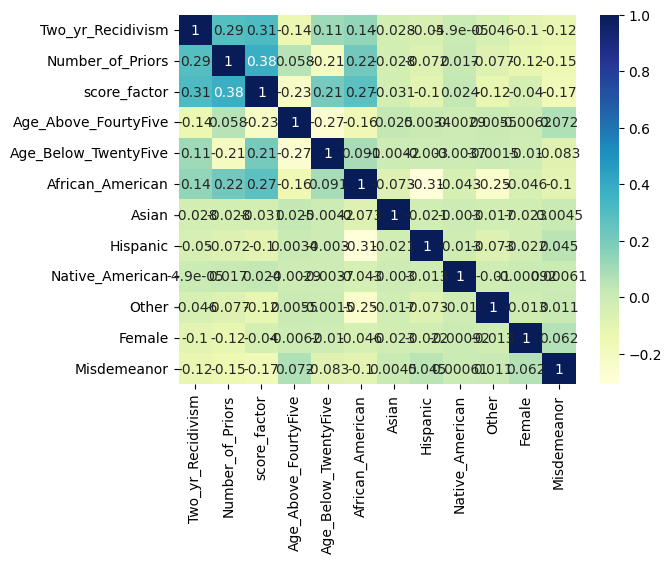

In [13]:
# Import necessary modules
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load dataset
data = pd.read_csv("data/propublica_data_for_fairml.csv")
# data.drop(labels=['race','age','sex'], axis=1, inplace=True)
print(data.columns)
# Compute correlation matrix
co_mtx = data.corr(numeric_only=True)

# Print correlation matrix
print(co_mtx)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

# Display heatmap
plt.show()

                      Two_yr_Recidivism  Number_of_Priors  score_factor  \
Two_yr_Recidivism              1.000000          0.290607      0.314832   
Number_of_Priors               0.290607          1.000000      0.380650   
score_factor                   0.314832          0.380650      1.000000   
Age_Above_FourtyFive          -0.139490          0.058449     -0.233351   
Age_Below_TwentyFive           0.111027         -0.211281      0.209613   
African_American               0.140609          0.215184      0.269905   
Asian                         -0.028115         -0.028334     -0.031436   
Hispanic                      -0.050453         -0.072447     -0.101760   
Native_American               -0.000049          0.017240      0.023935   
Other                         -0.045596         -0.076714     -0.117930   
Female                        -0.100911         -0.118722     -0.039625   
Misdemeanor                   -0.120332         -0.145433     -0.167039   

                      Ag

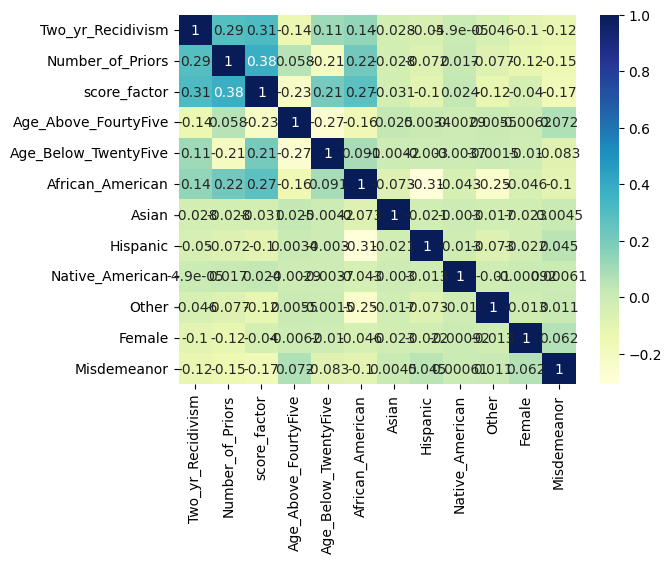

In [3]:
# Import necessary modules
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load dataset
data = pd.read_csv("data/propublica_data_for_fairml.csv")

# Compute correlation matrix
co_mtx = data.corr(numeric_only=True)

# Print correlation matrix
print(co_mtx)

# Plot correlation heatmap
sns.heatmap(co_mtx, cmap="YlGnBu", annot=True)

# Display heatmap
plt.show()